Usable images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


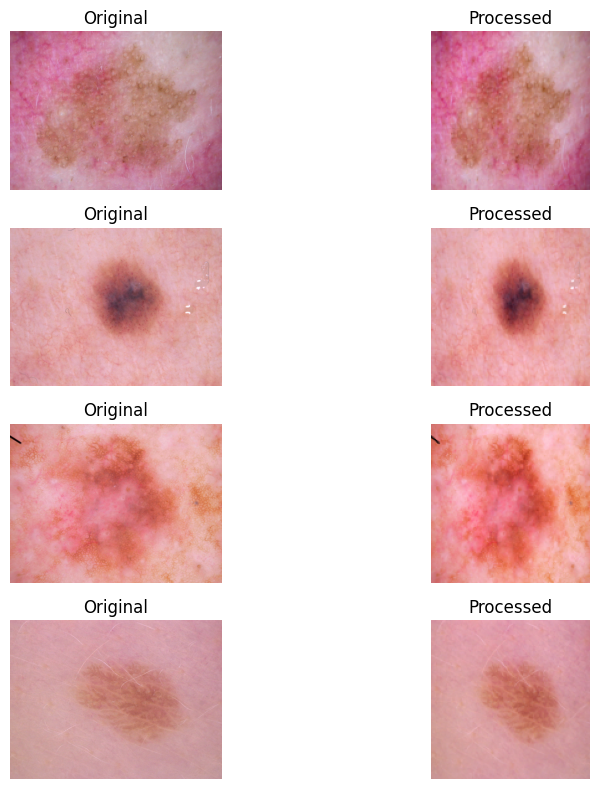

Processed 0 images...
Processed 500 images...
Processed 1000 images...
Processed 1500 images...
Processed 2000 images...
Processed 2500 images...
Processed 3000 images...
Processed 3500 images...
Processed 4000 images...
Processed 4500 images...
Processed 5000 images...
Processed 5500 images...
Processed 6000 images...
Processed 6500 images...
Processed 7000 images...
Processed 7500 images...
Processed 8000 images...
Processed 8500 images...
Processed 9000 images...
Processed 9500 images...
Processed 10000 images...

Feature matrix shape: (10015, 3208)

Label mapping:
0 akiec
1 bcc
2 bkl
3 df
4 mel
5 nv
6 vasc

Train size: 7010
Val size: 1502
Test size: 1503

Training Random Forest...

Validation Accuracy: 0.7217043941411452

Validation Classification Report:
              precision    recall  f1-score   support

       akiec       0.63      0.24      0.35        49
         bcc       0.63      0.31      0.42        77
         bkl       0.52      0.28      0.37       165
          df 

/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

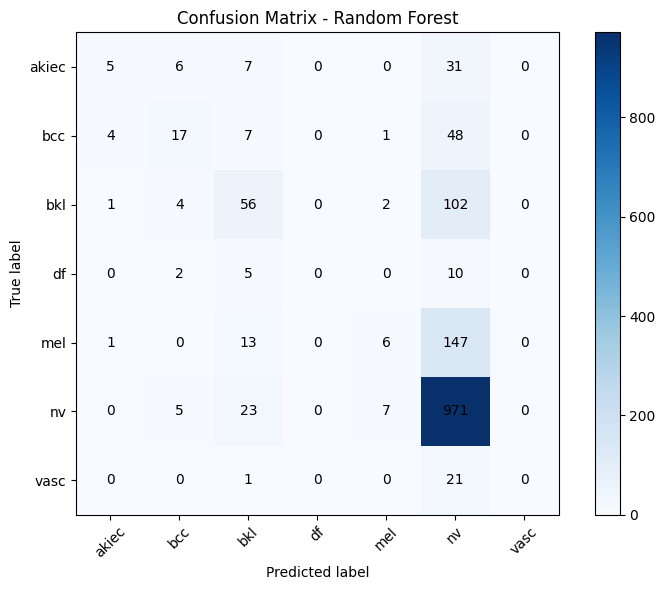

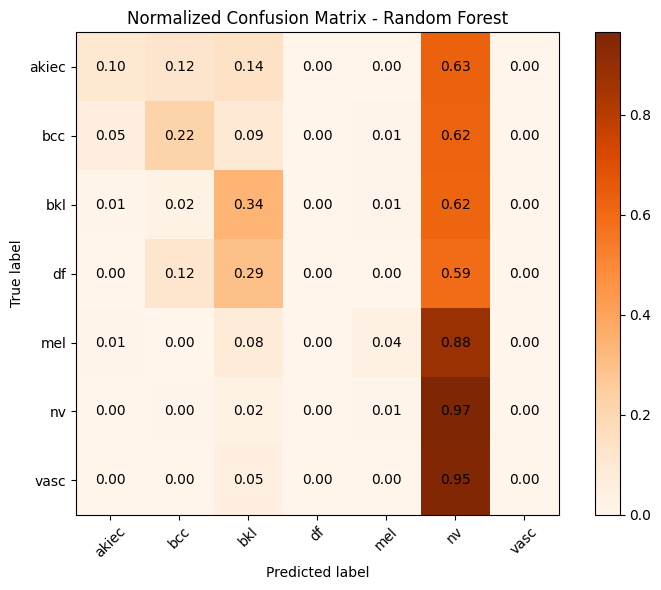

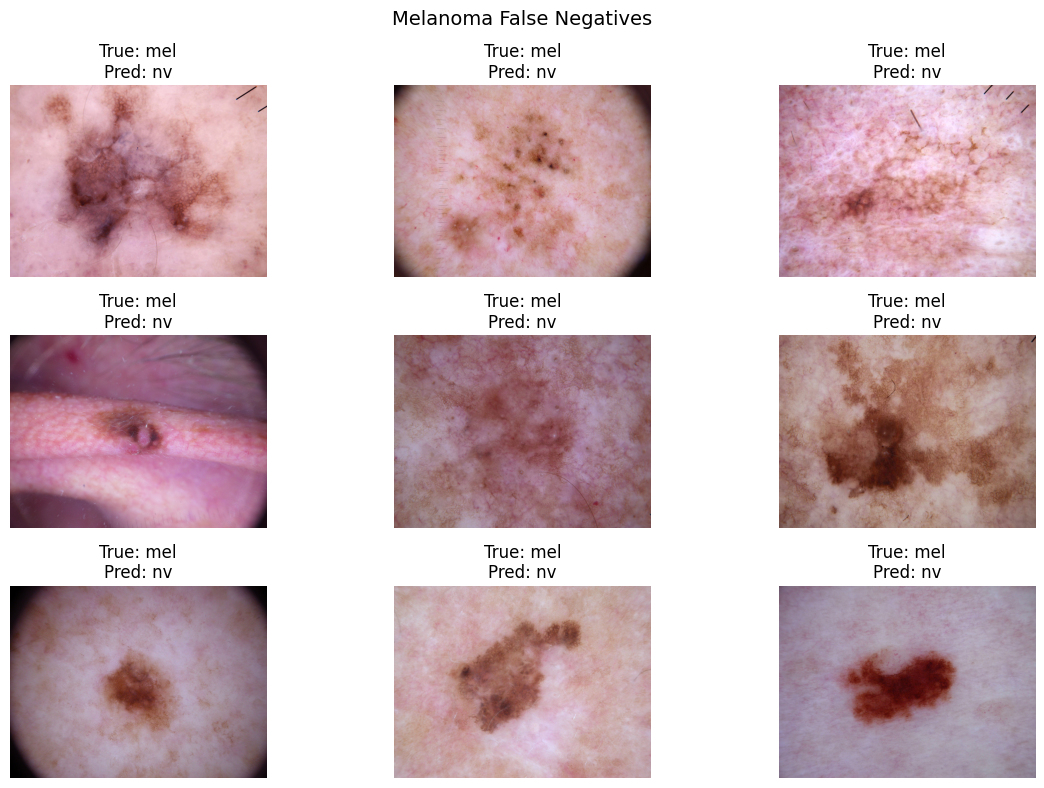

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score
)

CSV_PATH = "HAM10000_metadata.csv"
IMG_DIR_1 = "HAM10000_images_part_1"
IMG_DIR_2 = "HAM10000_images_part_2"


# 2. LOAD METADATA

df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].copy()

def get_image_path(image_id):
    p1 = os.path.join(IMG_DIR_1, f"{image_id}.jpg")
    p2 = os.path.join(IMG_DIR_2, f"{image_id}.jpg")
    if os.path.exists(p1):
        return p1
    if os.path.exists(p2):
        return p2
    return None

df["path"] = df["image_id"].apply(get_image_path)
df = df[df["path"].notnull()].reset_index(drop=True)

print("Usable images:", len(df))
print("\nClass distribution:")
print(df["dx"].value_counts())


def enhance_contrast_pil(img, factor=1.2):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(factor)

def crop_dark_borders(img, dark_threshold=20):
    """
    Removes obvious dark border/corner regions.
    """
    img_np = np.array(img)
    gray = np.mean(img_np, axis=2)

    mask = gray > dark_threshold
    if mask.sum() == 0:
        return img

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    h, w = gray.shape
    if (y1 - y0) < 0.5 * h or (x1 - x0) < 0.5 * w:
        return img

    return img.crop((x0, y0, x1, y1))

def crop_to_lesion(img, padding_ratio=0.15):
    """
    Simple lesion-centered crop:
    assumes lesion tends to be darker than the border/background skin.
    """
    img_np = np.array(img).astype(np.float32)
    gray = img_np.mean(axis=2)

    border_pixels = np.concatenate([
        gray[0, :], gray[-1, :], gray[:, 0], gray[:, -1]
    ])
    bg = np.median(border_pixels)

    mask = gray < (bg * 0.9)

    if mask.sum() < 0.01 * mask.size:
        return img

    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    h, w = gray.shape
    box_h = y1 - y0
    box_w = x1 - x0

    pad_y = int(box_h * padding_ratio)
    pad_x = int(box_w * padding_ratio)

    y0 = max(0, y0 - pad_y)
    x0 = max(0, x0 - pad_x)
    y1 = min(h, y1 + pad_y)
    x1 = min(w, x1 + pad_x)

    if (y1 - y0) < 0.2 * h or (x1 - x0) < 0.2 * w:
        return img

    return img.crop((x0, y0, x1, y1))

def preprocess_image(img_path, final_size=(64, 64), contrast_factor=1.2):
    img = Image.open(img_path).convert("RGB")
    img = crop_dark_borders(img, dark_threshold=20)
    img = crop_to_lesion(img, padding_ratio=0.15)
    img = enhance_contrast_pil(img, factor=contrast_factor)
    img = img.resize(final_size)
    return img



def extract_features_preprocessed(img_path, hist_bins=32, resize_for_pixels=(32, 32)):
    img = preprocess_image(img_path, final_size=(64, 64), contrast_factor=1.2)
    img_np = np.array(img)

    # RGB histograms
    hist_r, _ = np.histogram(img_np[:, :, 0], bins=hist_bins, range=(0, 256))
    hist_g, _ = np.histogram(img_np[:, :, 1], bins=hist_bins, range=(0, 256))
    hist_b, _ = np.histogram(img_np[:, :, 2], bins=hist_bins, range=(0, 256))
    color_hist = np.concatenate([hist_r, hist_g, hist_b]).astype(np.float32)
    color_hist /= (color_hist.sum() + 1e-8)

    # grayscale histogram
    gray = np.mean(img_np, axis=2).astype(np.uint8)
    gray_hist, _ = np.histogram(gray, bins=32, range=(0, 256))
    gray_hist = gray_hist.astype(np.float32)
    gray_hist /= (gray_hist.sum() + 1e-8)

    # simple statistics
    stats = np.array([
        img_np[:, :, 0].mean(), img_np[:, :, 1].mean(), img_np[:, :, 2].mean(),
        img_np[:, :, 0].std(),  img_np[:, :, 1].std(),  img_np[:, :, 2].std(),
        gray.mean(), gray.std()
    ], dtype=np.float32) / 255.0

    # downsampled raw pixels
    small_img = img.resize(resize_for_pixels)
    pixel_features = np.array(small_img).astype(np.float32).flatten() / 255.0

    return np.concatenate([color_hist, gray_hist, stats, pixel_features])


sample_paths = df["path"].sample(4, random_state=42).tolist()

plt.figure(figsize=(10, 8))
for i, path in enumerate(sample_paths):
    original = Image.open(path).convert("RGB")
    processed = preprocess_image(path, final_size=(128, 128), contrast_factor=1.2)

    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4, 2, 2 * i + 2)
    plt.imshow(processed)
    plt.title("Processed")
    plt.axis("off")

plt.tight_layout()
plt.show()


X = []
for i, path in enumerate(df["path"]):
    if i % 500 == 0:
        print(f"Processed {i} images...")
    X.append(extract_features_preprocessed(path))

X = np.array(X, dtype=np.float32)
y = df["dx"].values

print("\nFeature matrix shape:", X.shape)


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)

train_df, temp_df, X_train, X_temp, y_train, y_temp = train_test_split(
    df, X, y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

val_df, test_df, X_val, X_test, y_val, y_test = train_test_split(
    temp_df, X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

y_val_pred = rf_model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))


y_test_pred = rf_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_test_pred)
print("\nTest Confusion Matrix:")
print(cm)

# melanoma recall
mel_index = label_encoder.transform(["mel"])[0]
mel_recall = recall_score(y_test, y_test_pred, labels=[mel_index], average=None)[0]
print("\nMelanoma Recall:", mel_recall)


plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation="nearest", cmap="Oranges")
plt.title("Normalized Confusion Matrix - Random Forest")
plt.colorbar()

plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


fn_indices = np.where((y_test == mel_index) & (y_test_pred != mel_index))[0]

num_show = min(9, len(fn_indices))
plt.figure(figsize=(12, 8))

for i, idx in enumerate(fn_indices[:num_show]):
    plt.subplot(3, 3, i + 1)

    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)

    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma False Negatives", fontsize=14)
plt.tight_layout()
plt.show()